In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, glob, os
import scipy.stats as stats, scipy.io as sio

### Objective
0. Run after neur3.ipynb
1. Visualize trial contrasted PSTH for example patient
2. Encoding analyses across all patients

In [2]:
patient = 12

### load df_psychopy (for trial ids), df_neural (for region labels), and epoch spike/FR/bin arrays  for this patient

In [3]:
print(f'patient {patient}\n')
# load df_psychopy
df_psychopy_all = pd.read_csv('../../results/psychopy/all_subjs_clean.csv')
df_psychopy  = df_psychopy_all.loc[df_psychopy_all['subj'] == patient].reset_index(drop=True)
print(f'df_psychopy (trials by neurs): {df_psychopy.shape}\n')

# load df_neur
pt_data_dir = f'../../results/2025{patient}/records/processed_data'

df_neurs = pd.read_parquet(f'{pt_data_dir}/df_neurs.parquet')
print(f'df_neur (number of neurons): {len(df_neurs)}\n')

# load 2d spike, 3d FR and 1d bin arrays for all epochs
pt_data_dir = f'../../results/2025{patient}/records/processed_data'
epochs = ['baseline', 'stim', 'delay', 'response', 'feedback']
epoch_spikes, epoch_FRs, epoch_bins = {}, {}, {}

print('df spikes/FR/bins:')
for epoch in epochs:
    epoch_spikes[epoch] = np.load(f'{pt_data_dir}/{epoch}_spikes.npy', allow_pickle=True)
    epoch_FRs[epoch] = np.load(f'{pt_data_dir}/{epoch}_FRs.npy', allow_pickle=True)
    epoch_bins[epoch] = np.load(f'{pt_data_dir}/{epoch}_bin_centers.npy', allow_pickle=True)
    print(f'{epoch} spikes {epoch_spikes[epoch].shape}, FRs shape: {epoch_FRs[epoch].shape}, bins shape: {epoch_bins[epoch].shape}')

n_trials, n_neurs = epoch_FRs['baseline'].shape[:2]

# mean base_FR in case normalizing
mean_base_FR = epoch_FRs['baseline'].mean(axis=0)

patient 12

df_psychopy (trials by neurs): (240, 146)

df_neur (number of neurons): 32

df spikes/FR/bins:
baseline spikes (240, 32), FRs shape: (240, 32, 100), bins shape: (100,)
stim spikes (240, 32), FRs shape: (240, 32, 125), bins shape: (125,)
delay spikes (240, 32), FRs shape: (240, 32, 175), bins shape: (175,)
response spikes (240, 32), FRs shape: (240, 32, 100), bins shape: (100,)
feedback spikes (240, 32), FRs shape: (240, 32, 125), bins shape: (125,)


### helpers

In [4]:
def get_normed_FRs(FRs, base_FRs):
    return FRs - base_FRs.mean(axis=(0, 2), keepdims=True)


def get_contrast_in_epoch(df_psychopy, contrast):
    ''' split pre-loaded epoch arrays by contrast,
    return list of trial indices for each contrast group and their labels '''

    cont_trials, cont_labels = [], []

    if contrast == 'valence':
        cont_trials.append(df_psychopy[df_psychopy['stim_pos_aligned'] > df_psychopy['div_pos_aligned']].index)
        cont_trials.append(df_psychopy[df_psychopy['stim_pos_aligned'] < df_psychopy['div_pos_aligned']].index)
        cont_labels += ['gain', 'loss']
    elif contrast == 'ambiguity':
        cont_trials.append(df_psychopy[~df_psychopy['uncertainty']].index)
        cont_trials.append(df_psychopy[df_psychopy['uncertainty']].index)
        cont_labels += ['certain', 'uncertain']
    elif contrast == 'resp_dir':
        cont_trials.append(df_psychopy[df_psychopy['chosen_pos'] > df_psychopy['div_pos']].index)
        cont_trials.append(df_psychopy[df_psychopy['chosen_pos'] < df_psychopy['div_pos']].index)
        cont_labels += ['right', 'left']
    elif contrast == 'normed_RT':
        median_rt = df_psychopy['normed_RT'].median()
        cont_trials.append(df_psychopy[df_psychopy['normed_RT'] <= median_rt].index)
        cont_trials.append(df_psychopy[df_psychopy['normed_RT'] > median_rt].index)
        cont_labels += ['fast', 'slow']
    elif contrast == 'outcome': # feedback
        for val, label in zip([3, 1, -1, -3], ['3 coins', '1 coin', '-1 coin', '-3 coins']):
            cont_trials.append(df_psychopy[df_psychopy['outcome'] == val].index)
            cont_labels.append(label)
    elif contrast == 'boundary_context':
        for cond in ['curv_comp', 'baseline', 'flat_comp']:
            cont_trials.append(df_psychopy[df_psychopy['condition'] == cond].index)
            cont_labels.append(cond)
    elif contrast == 'baseline vs compressed conditions':
        cont_trials.append(df_psychopy[df_psychopy['condition'] != 'baseline'].index)
        cont_trials.append(df_psychopy[df_psychopy['condition'] == 'baseline'].index)
        cont_labels += ['comp', 'base']
    else:
        raise ValueError(f'Invalid contrast: {contrast}')

    print(f'contrast: {contrast} | #trials per group should be ~240/num_contrasts')
    return cont_trials, cont_labels

### 1. contrasted rasters + PSTHs

contrast: boundary_context | #trials per group should be ~240/num_contrasts


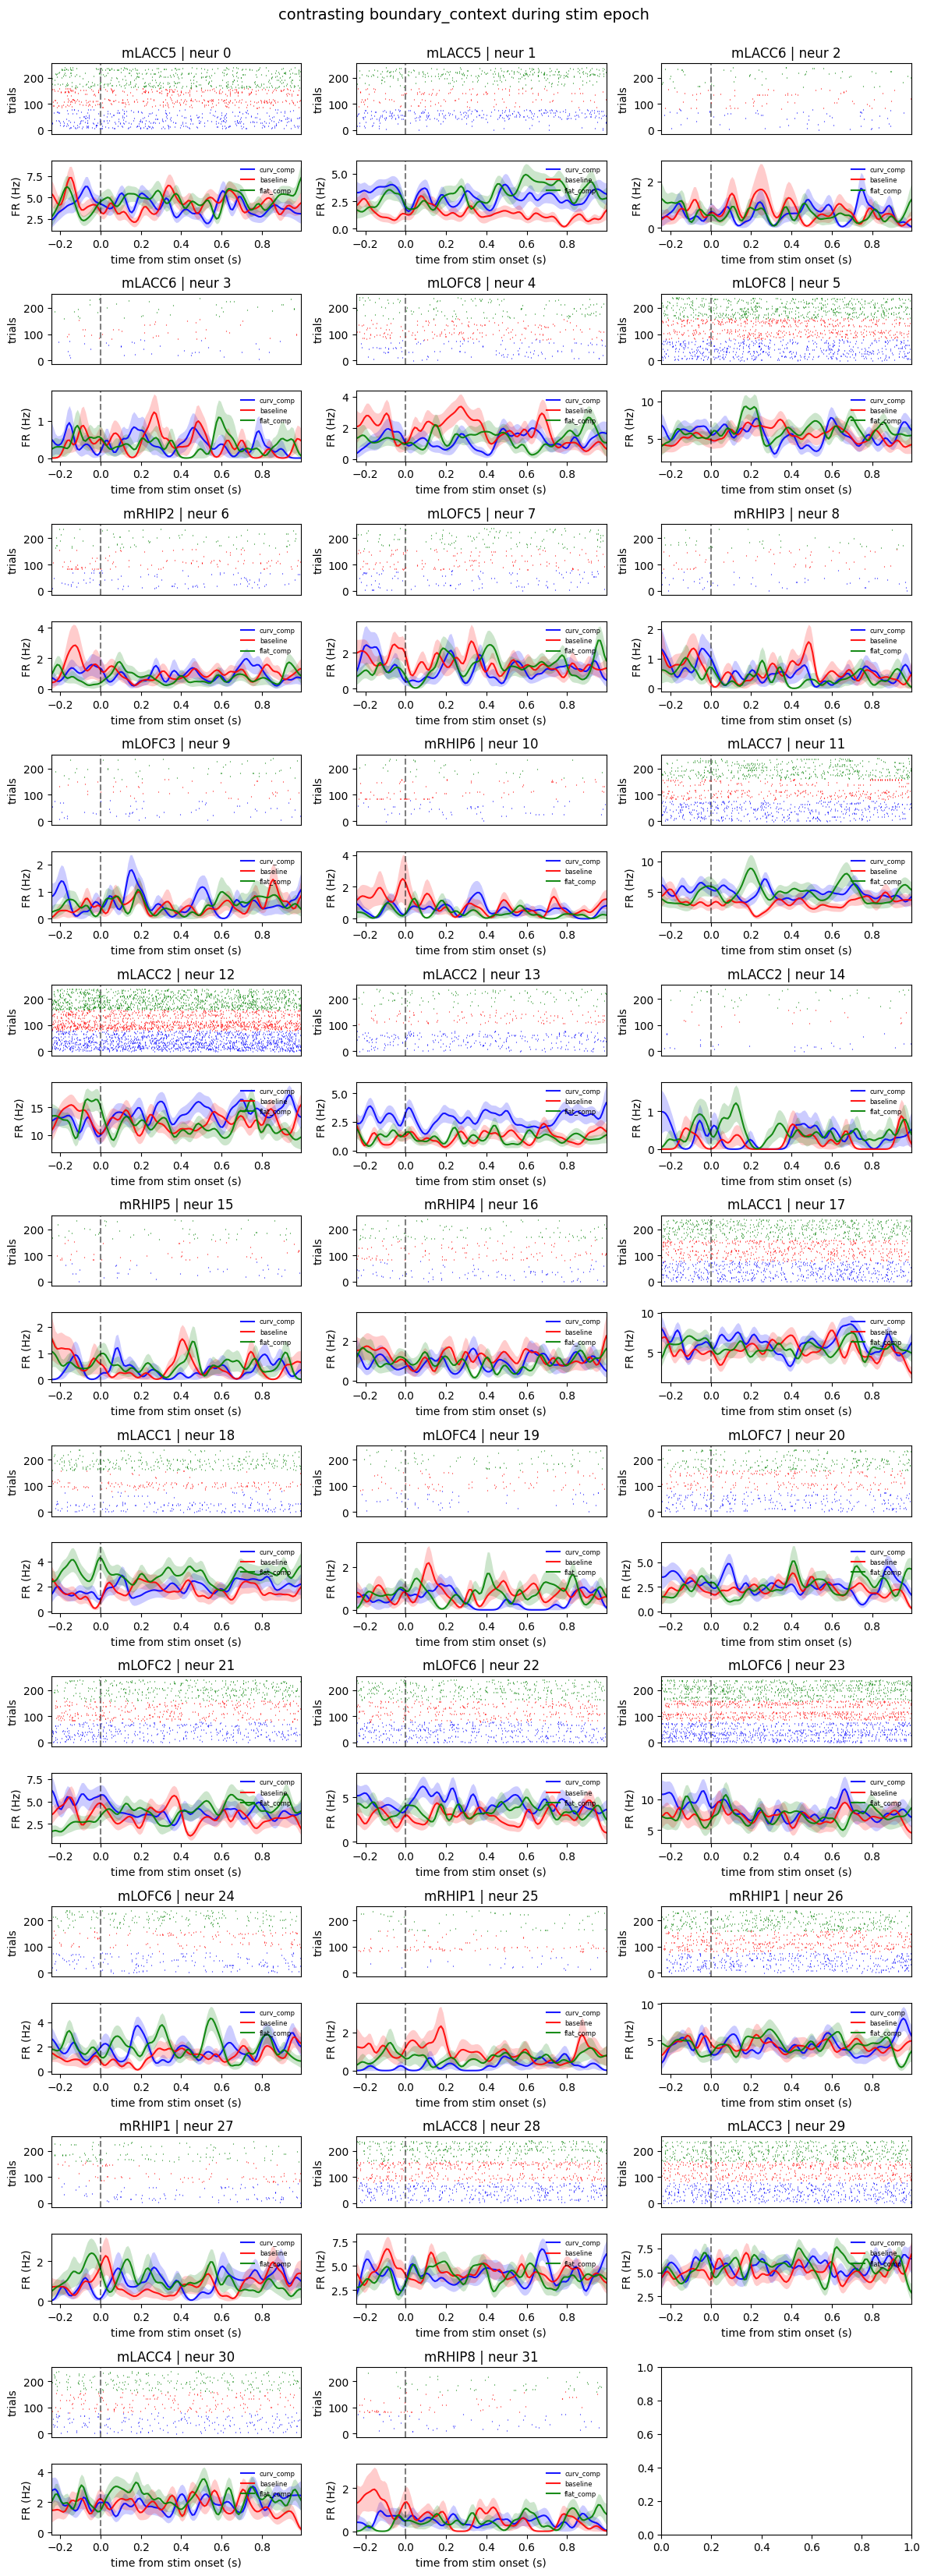

In [5]:
# choice params
norm, epoch, contrast = False, 'stim', 'boundary_context'

# grab relevant epoch data
spikes, FRs, bins = epoch_spikes[epoch], epoch_FRs[epoch], epoch_bins[epoch]

# get indices and labels for specified contrasts
cont_trials, cont_labels = get_contrast_in_epoch(df_psychopy, contrast)

# norming stuff
if norm: normed_FRs, yaxis_lab = get_normed_FRs(FRs, mean_base_FR), 'norm. '
else: normed_FRs, yaxis_lab = FRs.copy(), ''

# plot
n_cols = 3
n_rows = int(np.ceil(n_neurs / n_cols))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3))
axs, ax_idx = axs.flatten(), 0
colors = ['b', 'r', 'g', 'k'] # contrast colors

for neur_id in range(n_neurs):
    if ax_idx >= len(axs): break

    # reconfigure each neur's subplot into 2 rows: raster on top, psth on bottom
    ss = axs[ax_idx].get_subplotspec()
    axs[ax_idx].remove()

    # create new subplotspec for raster and psth
    gs = ss.subgridspec(2, 1, height_ratios=[1, 1])
    ax_raster = fig.add_subplot(gs[0])
    ax_psth   = fig.add_subplot(gs[1], sharex=ax_raster)

    # raster
    raster_trial_list, color_trial_list = [], []
    for idx in range(len(cont_labels)):
        raster_trial_list.extend(list(spikes[cont_trials[idx], neur_id]))
        color_trial_list.extend([colors[idx]] * len(cont_trials[idx]))

    ax_raster.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax_raster.eventplot(raster_trial_list, orientation='horizontal', colors=color_trial_list, linewidths=0.8, linelengths=3.0)
    ax_raster.set(title=f"{df_neurs['region'].iloc[neur_id]} | neur {neur_id}", ylabel='trials')
    ax_raster.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    # psth
    for idx in range(len(cont_labels)):
        cont_data = normed_FRs[cont_trials[idx], neur_id, :]
        mu = cont_data.mean(axis=0)
        sderr = (cont_data.std(axis=0, ddof=1) / np.sqrt(cont_data.shape[0])
                 if cont_data.shape[0] > 1 else np.zeros_like(mu))
        ax_psth.plot(bins, mu, color=colors[idx], alpha=0.9, label=cont_labels[idx])
        ax_psth.fill_between(bins, mu - sderr, mu + sderr, color=colors[idx], alpha=0.2, linewidth=0)

    ax_psth.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax_psth.set(xlim=(bins[0], bins[-1]), ylabel=f'{yaxis_lab}FR (Hz)', xlabel=f'time from {epoch} onset (s)')
    ax_psth.legend(loc='upper right', fontsize=6, frameon=False)

    ax_idx += 1

plt.suptitle(f'contrasting {contrast} during {epoch} epoch', y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

### 2. encoding (all patients)

In [6]:
# make a list of patients with neural data
patients = df_psychopy_all['subj'].unique().tolist()
print(patients)

# drop patients without neural data
for patient in [9, 11, 21, 22]: patients.remove(patient)
print(f'neural patients: {patients}\n')

# load pt specific data and store a dict of patient->epoch_spike_arr
pt_base_spike_arr, pt_stim_spikes_arr, pt_delay_spike_arr, pt_response_spike_arr, pt_feedback_spike_arr = {}, {}, {}, {}, {}
for patient in patients:
    print(f'patient {patient}')
    
    pt_psychopy_df = df_psychopy_all.loc[df_psychopy_all['subj'] == patient].reset_index(drop=True)
    print(f'df_psychopy (num_trials): {len(pt_psychopy_df)}')

    pt_data_dir = f'../../results/2025{patient}/records/processed_data'
    pt_base_spike_arr[patient] = np.load(f'{pt_data_dir}/baseline_spikes.npy', allow_pickle=True)
    pt_stim_spikes_arr[patient] = np.load(f'{pt_data_dir}/stim_spikes.npy', allow_pickle=True)
    pt_delay_spike_arr[patient] = np.load(f'{pt_data_dir}/delay_spikes.npy', allow_pickle=True)
    pt_response_spike_arr[patient] = np.load(f'{pt_data_dir}/response_spikes.npy', allow_pickle=True)
    pt_feedback_spike_arr[patient] = np.load(f'{pt_data_dir}/feedback_spikes.npy', allow_pickle=True)

    print(f'stim spike_arr (trials, neurons): {pt_base_spike_arr[patient].shape}\n')


[9, 11, 12, 18, 21, 22]
neural patients: [12, 18]

patient 12
df_psychopy (num_trials): 240
stim spike_arr (trials, neurons): (240, 32)

patient 18
df_psychopy (num_trials): 240
stim spike_arr (trials, neurons): (240, 23)



In [16]:
patient = 18
alpha = 0.05
epoch = 'delay'
pt_df_neurs = pd.read_parquet(f'../../results/2025{patient}/records/processed_data/df_neurs.parquet')
pt_df_psychopy = df_psychopy_all.loc[df_psychopy_all['subj'] == patient].reset_index(drop=True)
cont_trials, cont_labels = get_contrast_in_epoch(pt_df_psychopy, 'boundary_context')

pt_spike_arr = pt_stim_spikes_arr[patient]
pt_neurs = pt_spike_arr.shape[1]
# ... rest unchanged
spike_counts = np.array([[len(pt_spike_arr[t, n]) for n in range(pt_neurs)] for t in range(pt_spike_arr.shape[0])])

# Kruskal-Wallis: does spike count differ across boundary_context conditions?
H_stats, pvals = np.full(pt_neurs, np.nan), np.full(pt_neurs, np.nan)
for n in range(pt_neurs):
    groups = [spike_counts[cont_trials[i], n] for i in range(len(cont_labels))]
    if any(len(g) < 2 for g in groups): continue
    H_stats[n], pvals[n] = stats.kruskal(*groups)

# FDR correction (Benjamini-Hochberg) on valid p-values only
valid = ~np.isnan(pvals)
pvals_fdr = np.full(pt_neurs, np.nan)
sig_mask = np.zeros(pt_neurs, dtype=bool)
try:
    from statsmodels.stats.multitest import fdrcorrection
    sig_mask[valid], pvals_fdr[valid] = fdrcorrection(pvals[valid], alpha=alpha)
except ImportError:
    print('statsmodels not found; falling back to Bonferroni correction')
    pvals_fdr[valid] = np.minimum(pvals[valid] * valid.sum(), 1.0)
    sig_mask[valid] = pvals_fdr[valid] < alpha

# results df
df_encoding = pd.DataFrame({'neur_id': np.arange(pt_neurs), 'region': pt_df_neurs['region'].values, 'H': H_stats,
                            'pval': pvals, 'pval_fdr': pvals_fdr, 'significant': sig_mask
                            })

print(f'patient {patient} |  {epoch} | boundary_context')
print(f'significant neurons (FDR q<{alpha}): {sig_mask.sum()} / {pt_neurs}\n')
if sig_mask.any():
    print(df_encoding[df_encoding['significant']][['neur_id', 'region', 'H', 'pval', 'pval_fdr']].to_string(index=False))
df_encoding


contrast: boundary_context | #trials per group should be ~240/num_contrasts
patient 18 |  delay | boundary_context
significant neurons (FDR q<0.05): 0 / 23



,neur_id,region,H,pval,pval_fdr,significant
0,0,mRAHIP2,1.647496,0.438784,0.720859,False
1,1,mRAHIP2,1.890115,0.388657,0.687624,False
2,2,mRAHIP2,0.955756,0.620098,0.809636,False
3,3,mRAHIP5,3.169521,0.204997,0.554997,False
4,4,mRAHIP5,4.373804,0.112264,0.516415,False
5,5,mROFC8,3.730431,0.154863,0.554997,False
6,6,mRACC7,0.894125,0.639504,0.809636,False
7,7,mRACC7,5.123719,0.077161,0.443676,False
8,8,mRAHIP8,0.730649,0.693971,0.809636,False
9,9,mRAHIP8,1.378438,0.501968,0.769684,False


### example neuron

In [ ]:
# reg = 'mLACC5'
# neur_id = df_neurs[df_neurs['region'] == reg].index[0]
# colors = ['b', 'r', 'g', 'k']

# fig, axs = plt.subplots(2, 1, figsize=(4, 6), sharex=True)

# # raster
# raster_trial_list, color_trial_list = [], []
# for indx in [1, 0]:
#     cont_label, cont_trial, cont_color = cont_labels[indx], cont_trials[indx], colors[indx]
#     raster_trial_list.extend(list(spikes[cont_trial, neur_id]))
#     color_trial_list.extend([cont_color] * len(cont_trial))

# axs[0].axvline(0, color='k', linestyle='--', alpha=0.5)
# axs[0].eventplot(raster_trial_list, orientation='horizontal', colors=color_trial_list, linewidths=1.0, linelengths=3.0)
# axs[0].set_ylabel('sorted trials')

# # psth
# for indx in range(len(cont_labels)):
#     cont_label, cont_trial, cont_color = cont_labels[indx], cont_trials[indx], colors[indx]
#     data = normed_FRs[cont_trial, neur_id, :]
#     mu = data.mean(axis=0)
#     sderr = (data.std(axis=0, ddof=1) / np.sqrt(data.shape[0])) if data.shape[0] > 1 else np.zeros_like(mu)
#     axs[1].plot(bins, mu, color=cont_color, alpha=0.9, label=cont_label)
#     axs[1].fill_between(bins, mu - sderr, mu + sderr, color=cont_color, alpha=0.2, linewidth=0)

# axs[1].axvline(0, color='k', linestyle='--', alpha=0.5)
# axs[1].set_ylabel('normed FR (Hz)')
# axs[1].set_xlabel(f'time from {epoch} onset (s)')
# axs[1].legend(loc='upper right')
# plt.tight_layout()
# plt.show()